## Preparation

In [48]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import GroupShuffleSplit, train_test_split
import pandas as pd
import pickle
import sys
import math
import random
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
!{sys.executable} -m pip install -q "pyarrow>=13.0.0"

df = pd.read_pickle(
    r"C:\Users\Juli\Documents\Master\Projekt Genomforschung\Datasets\harmonized_data.pkl"
)

## Models

We use the cross-attention fusion model.

In [38]:
class CrossAttentionFusionModel(nn.Module):
    def __init__(self, gene_dim=978, chem_dim=1032, hidden_dim=32, num_tokens=4, num_heads=4, dropout=0.3):
        super().__init__()
        self.num_tokens = num_tokens
        self.hidden_dim = hidden_dim
        
        self.input_dropout_gene = nn.Dropout(0.2)
        self.input_dropout_chem = nn.Dropout(0.3)

        self.gene_encoder = nn.Sequential(
            nn.Linear(gene_dim, num_tokens * hidden_dim),
            nn.BatchNorm1d(num_tokens * hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.drug_encoder = nn.Sequential(
            nn.Linear(chem_dim, num_tokens * hidden_dim),
            nn.BatchNorm1d(num_tokens * hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        # Cross-attention mechanism using 4 attention heads.
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        # Layer normalization for gene and drug tokens after cross-attention.
        self.norm_gene = nn.LayerNorm(hidden_dim)
        self.norm_drug = nn.LayerNorm(hidden_dim)
        # Final regressor that takes the concatenated gene and drug representations and outputs a single prediction.
        # Multi-Layer Perceptron (MLP)
        self.regressor = nn.Sequential(
            nn.Linear(num_tokens * hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
    
    def forward(self, x_gene, x_drug):
        batch_size = x_gene.size(0)
        x_gene = self.input_dropout_gene(x_gene)
        x_drug = self.input_dropout_chem(x_drug)

        gene_tokens = self.gene_encoder(x_gene).view(batch_size, self.num_tokens, self.hidden_dim)
        drug_tokens = self.drug_encoder(x_drug).view(batch_size, self.num_tokens, self.hidden_dim)

        gene_attn_out, gene_attn_weights = self.cross_attn(
            query=gene_tokens, key=drug_tokens, value=drug_tokens
        )
        drug_attn_out, drug_attn_weights = self.cross_attn(
            query=drug_tokens, key=gene_tokens, value=gene_tokens
        )
        self.last_attn_weights = {
            "gene_to_drug": gene_attn_weights.detach().cpu().numpy(),
            "drug_to_gene": drug_attn_weights.detach().cpu().numpy(),
        }

        gene_context = self.norm_gene(gene_tokens + gene_attn_out)
        drug_context = self.norm_drug(drug_tokens + drug_attn_out)

        fused = torch.cat(
            [gene_context.view(batch_size, -1), drug_context.view(batch_size, -1)],
            dim=1
        )
        pred = self.regressor(fused)
        return pred.squeeze(1)

In [3]:
class AdvancedSelfAndCrossAttentionModel(nn.Module):
    def __init__(self, gene_dim=978, chem_dim=1032, hidden_dim=64, num_heads=4, num_tokens=8, dropout=0.3):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        self.num_tokens = num_tokens
        
        # encoder: Projizieren die flachen Features in eine Token-Sequenz (Batch, num_tokens, hidden_dim)
        self.gene_encoder = nn.Sequential(
            nn.Linear(gene_dim, num_tokens * hidden_dim),
            nn.LayerNorm(num_tokens * hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.drug_encoder = nn.Sequential(
            nn.Linear(chem_dim, num_tokens * hidden_dim),
            nn.LayerNorm(num_tokens * hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Positional Encoding (Optional, aber hilfreich, damit die Attention die Token-IDs unterscheiden kann)
        self.gene_pos = nn.Parameter(torch.randn(1, num_tokens, hidden_dim))
        self.drug_pos = nn.Parameter(torch.randn(1, num_tokens, hidden_dim))

        # 2. SELF-ATTENTION: Jede Modalität kommuniziert erst mit sich selbst
        self.gene_self_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.drug_self_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        
        self.norm_self_gene = nn.LayerNorm(hidden_dim)
        self.norm_self_drug = nn.LayerNorm(hidden_dim)

        # 3. CROSS-ATTENTION: Chemie fragt Biologie ab
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.norm_cross = nn.LayerNorm(hidden_dim)

        # 4. REGRESSION HEAD
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x_gene, x_drug):
        batch_size = x_gene.size(0)

        # --- Schritt 1: In Tokens transformieren ---
        # Shape: (B, num_tokens, hidden_dim)
        gene_tokens = self.gene_encoder(x_gene).view(batch_size, self.num_tokens, self.hidden_dim)
        drug_tokens = self.drug_encoder(x_drug).view(batch_size, self.num_tokens, self.hidden_dim)
        
        # Positional Embedding addieren
        gene_tokens = gene_tokens + self.gene_pos
        drug_tokens = drug_tokens + self.drug_pos

        # --- Schritt 2: Echte Self-Attention (Intra-modal) ---
        # Biologie filtert eigenes Rauschen
        gene_self_out, _ = self.gene_self_attn(query=gene_tokens, key=gene_tokens, value=gene_tokens)
        gene_tokens = self.norm_self_gene(gene_tokens + gene_self_out)

        # Chemie ordnet funktionelle Gruppen aneinander an
        drug_self_out, _ = self.drug_self_attn(query=drug_tokens, key=drug_tokens, value=drug_tokens)
        drug_tokens = self.norm_self_drug(drug_tokens + drug_self_out)

        # --- Schritt 3: Cross-Attention (Inter-modal) ---
        # Chemie (Query) greift auf biologischen Kontext (Key/Value) zu
        cross_out, _ = self.cross_attn(query=drug_tokens, key=gene_tokens, value=gene_tokens)
        drug_context = self.norm_cross(drug_tokens + cross_out)

        # --- Schritt 4: Pooling & Fusion ---
        # Wir mitteln über die Token-Dimension (Mean Pooling)
        gene_repr = gene_tokens.mean(dim=1)  # Shape: (B, hidden_dim)
        drug_repr = drug_context.mean(dim=1) # Shape: (B, hidden_dim)

        # Konkatenerieren zu (B, hidden_dim * 2)
        fused = torch.cat([gene_repr, drug_repr], dim=1)

        # Vorhersage
        pred = self.regressor(fused)
        return pred.squeeze(1)

Der DataLoader kümmert sich darum, dass das Modell die Daten in Batches bekommt

## Training data

In [98]:
# training data group split in train val
target = 'LN_IC50'
pharmacophores = ['Donor', 'Acceptor', 'Aromatic', 'Hydrophobe', 'LumpedHydrophobe', 'PosIonizable', 'NegIonizable', 'ZnBinder']
mfp_cols = [col for col in df.columns if col.startswith('Bit_')]
X_genomic = df.filter(regex=r'.* \(.*\)').values.astype('float32')
X_chem = df[pharmacophores + mfp_cols]
y = df[target].values.astype('float32')

# split data into train and test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=6726)
idx_train_val, idx_test = next(gss_test.split(X_genomic, y, groups=df['DRUG_ID']))

# separate validation set from training set
groups_train_val = df['DRUG_ID'].iloc[idx_train_val]
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.11, random_state=42)
idx_train, idx_val = next(gss_val.split(X_genomic[idx_train_val], y[idx_train_val], groups=groups_train_val))

idx_train = idx_train_val[idx_train]
idx_val = idx_train_val[idx_val]

preprocessor = ColumnTransformer(
    transformers=[
        ('pharmacophore', StandardScaler(), pharmacophores),
        #('mfp', PCA(n_components=50, random_state=42), mfp_cols)
        ('mfp', 'passthrough', mfp_cols)
    ],
    remainder='drop'
)
gene_scaler = StandardScaler()

X_genomic_train = gene_scaler.fit_transform(X_genomic[idx_train])
X_chem_train = preprocessor.fit_transform(X_chem.iloc[idx_train])

X_genomic_val = gene_scaler.transform(X_genomic[idx_val])
X_chem_val = preprocessor.transform(X_chem.iloc[idx_val])

X_genomic_test = gene_scaler.transform(X_genomic[idx_test])
X_chem_test = preprocessor.transform(X_chem.iloc[idx_test])

# scale IC50 values
#scaler = StandardScaler()
y_train = y[idx_train]#scaler.fit_transform(y[idx_train].reshape(-1, 1)).flatten()
y_val = y[idx_val]#scaler.transform(y[idx_val].reshape(-1, 1)).flatten()
y_test = y[idx_test]#scaler.transform(y[idx_test].reshape(-1, 1)).flatten()

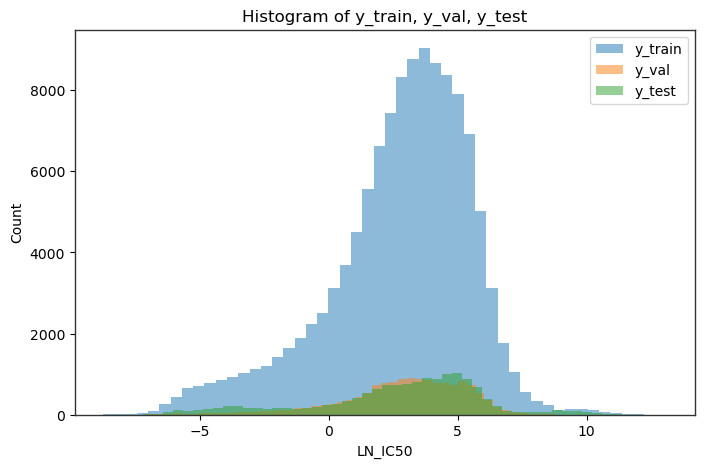

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(y_train, bins=50, alpha=0.5, label='y_train')
plt.hist(y_val, bins=50, alpha=0.5, label='y_val')
plt.hist(y_test, bins=50, alpha=0.5, label='y_test')
plt.xlabel('LN_IC50')
plt.ylabel('Count')
plt.title('Histogram of y_train, y_val, y_test')
plt.legend()
plt.show()

In [101]:
def make_loaders(batch_size=128, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        DrugResponseDataset(X_genomic_train, X_chem_train, y_train),
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        generator=g,
    )
    val_loader = DataLoader(
        DrugResponseDataset(X_genomic_val, X_chem_val, y_val),
        batch_size=batch_size,
        shuffle=False,
    )
    test_loader = DataLoader(
        DrugResponseDataset(X_genomic_test, X_chem_test, y_test),
        batch_size=batch_size,
        shuffle=False,
    )
    return train_loader, val_loader, test_loader

## Running 

best_model_7prozent oder so .pt saves the best model (lol) 

In [102]:
# created by copilot
hidden_dim = 32
dropout = 0.5
lr = 1e-3
patience = 6
epochs = 24
weight_decay = 1e-2
num_tokens = 5

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(6726)
train_loader, val_loader, test_loader = make_loaders(batch_size=128, seed=6726)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CrossAttentionFusionModel(
    gene_dim=X_genomic.shape[1],
    chem_dim=X_chem_train.shape[1],
    hidden_dim=hidden_dim,
    num_heads=4,
    dropout=dropout,
    num_tokens=num_tokens
).to(device)

criterion = nn.MSELoss()
#optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=patience
)

best_val_rmse = float("inf")
best_val_r2 = None
best_epoch = -1

print("Start Training")
for epoch in range(epochs):
    model.train()
    train_preds, train_targets = [], []
    train_loss = 0.0

    for batch_genes, batch_chem, batch_y in train_loader:
        batch_genes = batch_genes.to(device)
        batch_chem = batch_chem.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        predictions = model(batch_genes, batch_chem).view(-1)
        batch_y = batch_y.view(-1)

        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_genes.size(0)
        train_preds.extend(predictions.detach().cpu().numpy())
        train_targets.extend(batch_y.detach().cpu().numpy())

    total_train_loss = train_loss / len(train_loader.dataset)
    train_preds_orig = np.array(train_preds)
    train_targets_orig = np.array(train_targets)
    train_rmse_orig = root_mean_squared_error(train_targets_orig, train_preds_orig)

    model.eval()
    val_preds, val_targets = [], []
    val_loss = 0.0

    with torch.no_grad():
        for batch_genes, batch_chem, batch_y in val_loader:
            batch_genes = batch_genes.to(device)
            batch_chem = batch_chem.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_genes, batch_chem).view(-1)
            loss = criterion(predictions, batch_y.view(-1))

            val_loss += loss.item() * batch_genes.size(0)
            val_preds.extend(predictions.cpu().numpy())
            val_targets.extend(batch_y.cpu().numpy())

    total_val_loss = val_loss / len(val_loader.dataset)
    val_preds = np.array(val_preds)
    val_targets = np.array(val_targets)
    val_rmse = root_mean_squared_error(val_targets, val_preds)
    val_r2 = r2_score(val_targets, val_preds)

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_val_r2 = val_r2
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model.pt")

    scheduler.step(total_val_loss)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train RMSE: {train_rmse_orig:.4f} | "
        f"Val RMSE: {val_rmse:.4f} | "
        f"Val R²: {val_r2:.4f}"
    )

model.load_state_dict(torch.load("best_model.pt", weights_only=True))
model.eval()

test_preds, test_targets = [], []
with torch.no_grad():
    for batch_genes, batch_chem, batch_y in test_loader:
        batch_genes = batch_genes.to(device)
        batch_chem = batch_chem.to(device)
        batch_y = batch_y.to(device)

        predictions = model(batch_genes, batch_chem).view(-1)
        test_preds.extend(predictions.cpu().numpy())
        test_targets.extend(batch_y.cpu().numpy())

test_preds = np.array(test_preds)
test_targets = np.array(test_targets)

test_rmse = root_mean_squared_error(test_targets, test_preds)
test_r2 = r2_score(test_targets, test_preds)

print(f"Test RMSE: {test_rmse:.4f} | Test R²: {test_r2:.4f}")
print(
    f"Best model in epoch {best_epoch} with Val RMSE: {best_val_rmse:.4f} "
    f"and Val R²: {best_val_r2:.4f}"
)

Start Training
Epoch 01/24 | Train RMSE: 2.0166 | Val RMSE: 2.7071 | Val R²: -0.1853
Epoch 02/24 | Train RMSE: 1.7564 | Val RMSE: 2.8544 | Val R²: -0.3178
Epoch 03/24 | Train RMSE: 1.7072 | Val RMSE: 2.7492 | Val R²: -0.2225
Epoch 04/24 | Train RMSE: 1.6681 | Val RMSE: 2.8571 | Val R²: -0.3204
Epoch 05/24 | Train RMSE: 1.6440 | Val RMSE: 2.6856 | Val R²: -0.1666
Epoch 06/24 | Train RMSE: 1.6312 | Val RMSE: 2.8807 | Val R²: -0.3423
Epoch 07/24 | Train RMSE: 1.6223 | Val RMSE: 2.6616 | Val R²: -0.1459
Epoch 08/24 | Train RMSE: 1.6069 | Val RMSE: 2.7138 | Val R²: -0.1912
Epoch 09/24 | Train RMSE: 1.6009 | Val RMSE: 2.7879 | Val R²: -0.2572
Epoch 10/24 | Train RMSE: 1.5936 | Val RMSE: 2.5329 | Val R²: -0.0377
Epoch 11/24 | Train RMSE: 1.5902 | Val RMSE: 2.5108 | Val R²: -0.0197
Epoch 12/24 | Train RMSE: 1.5897 | Val RMSE: 2.5781 | Val R²: -0.0751
Epoch 13/24 | Train RMSE: 1.5858 | Val RMSE: 2.6801 | Val R²: -0.1619
Epoch 14/24 | Train RMSE: 1.5801 | Val RMSE: 2.5094 | Val R²: -0.0185
Epoch

## Visualization of results

First visualization of prediction of lnIC50 vs clinical classification. This first plot is not viable because I don't have any reasoning for the threshold. I picked it myself without references.

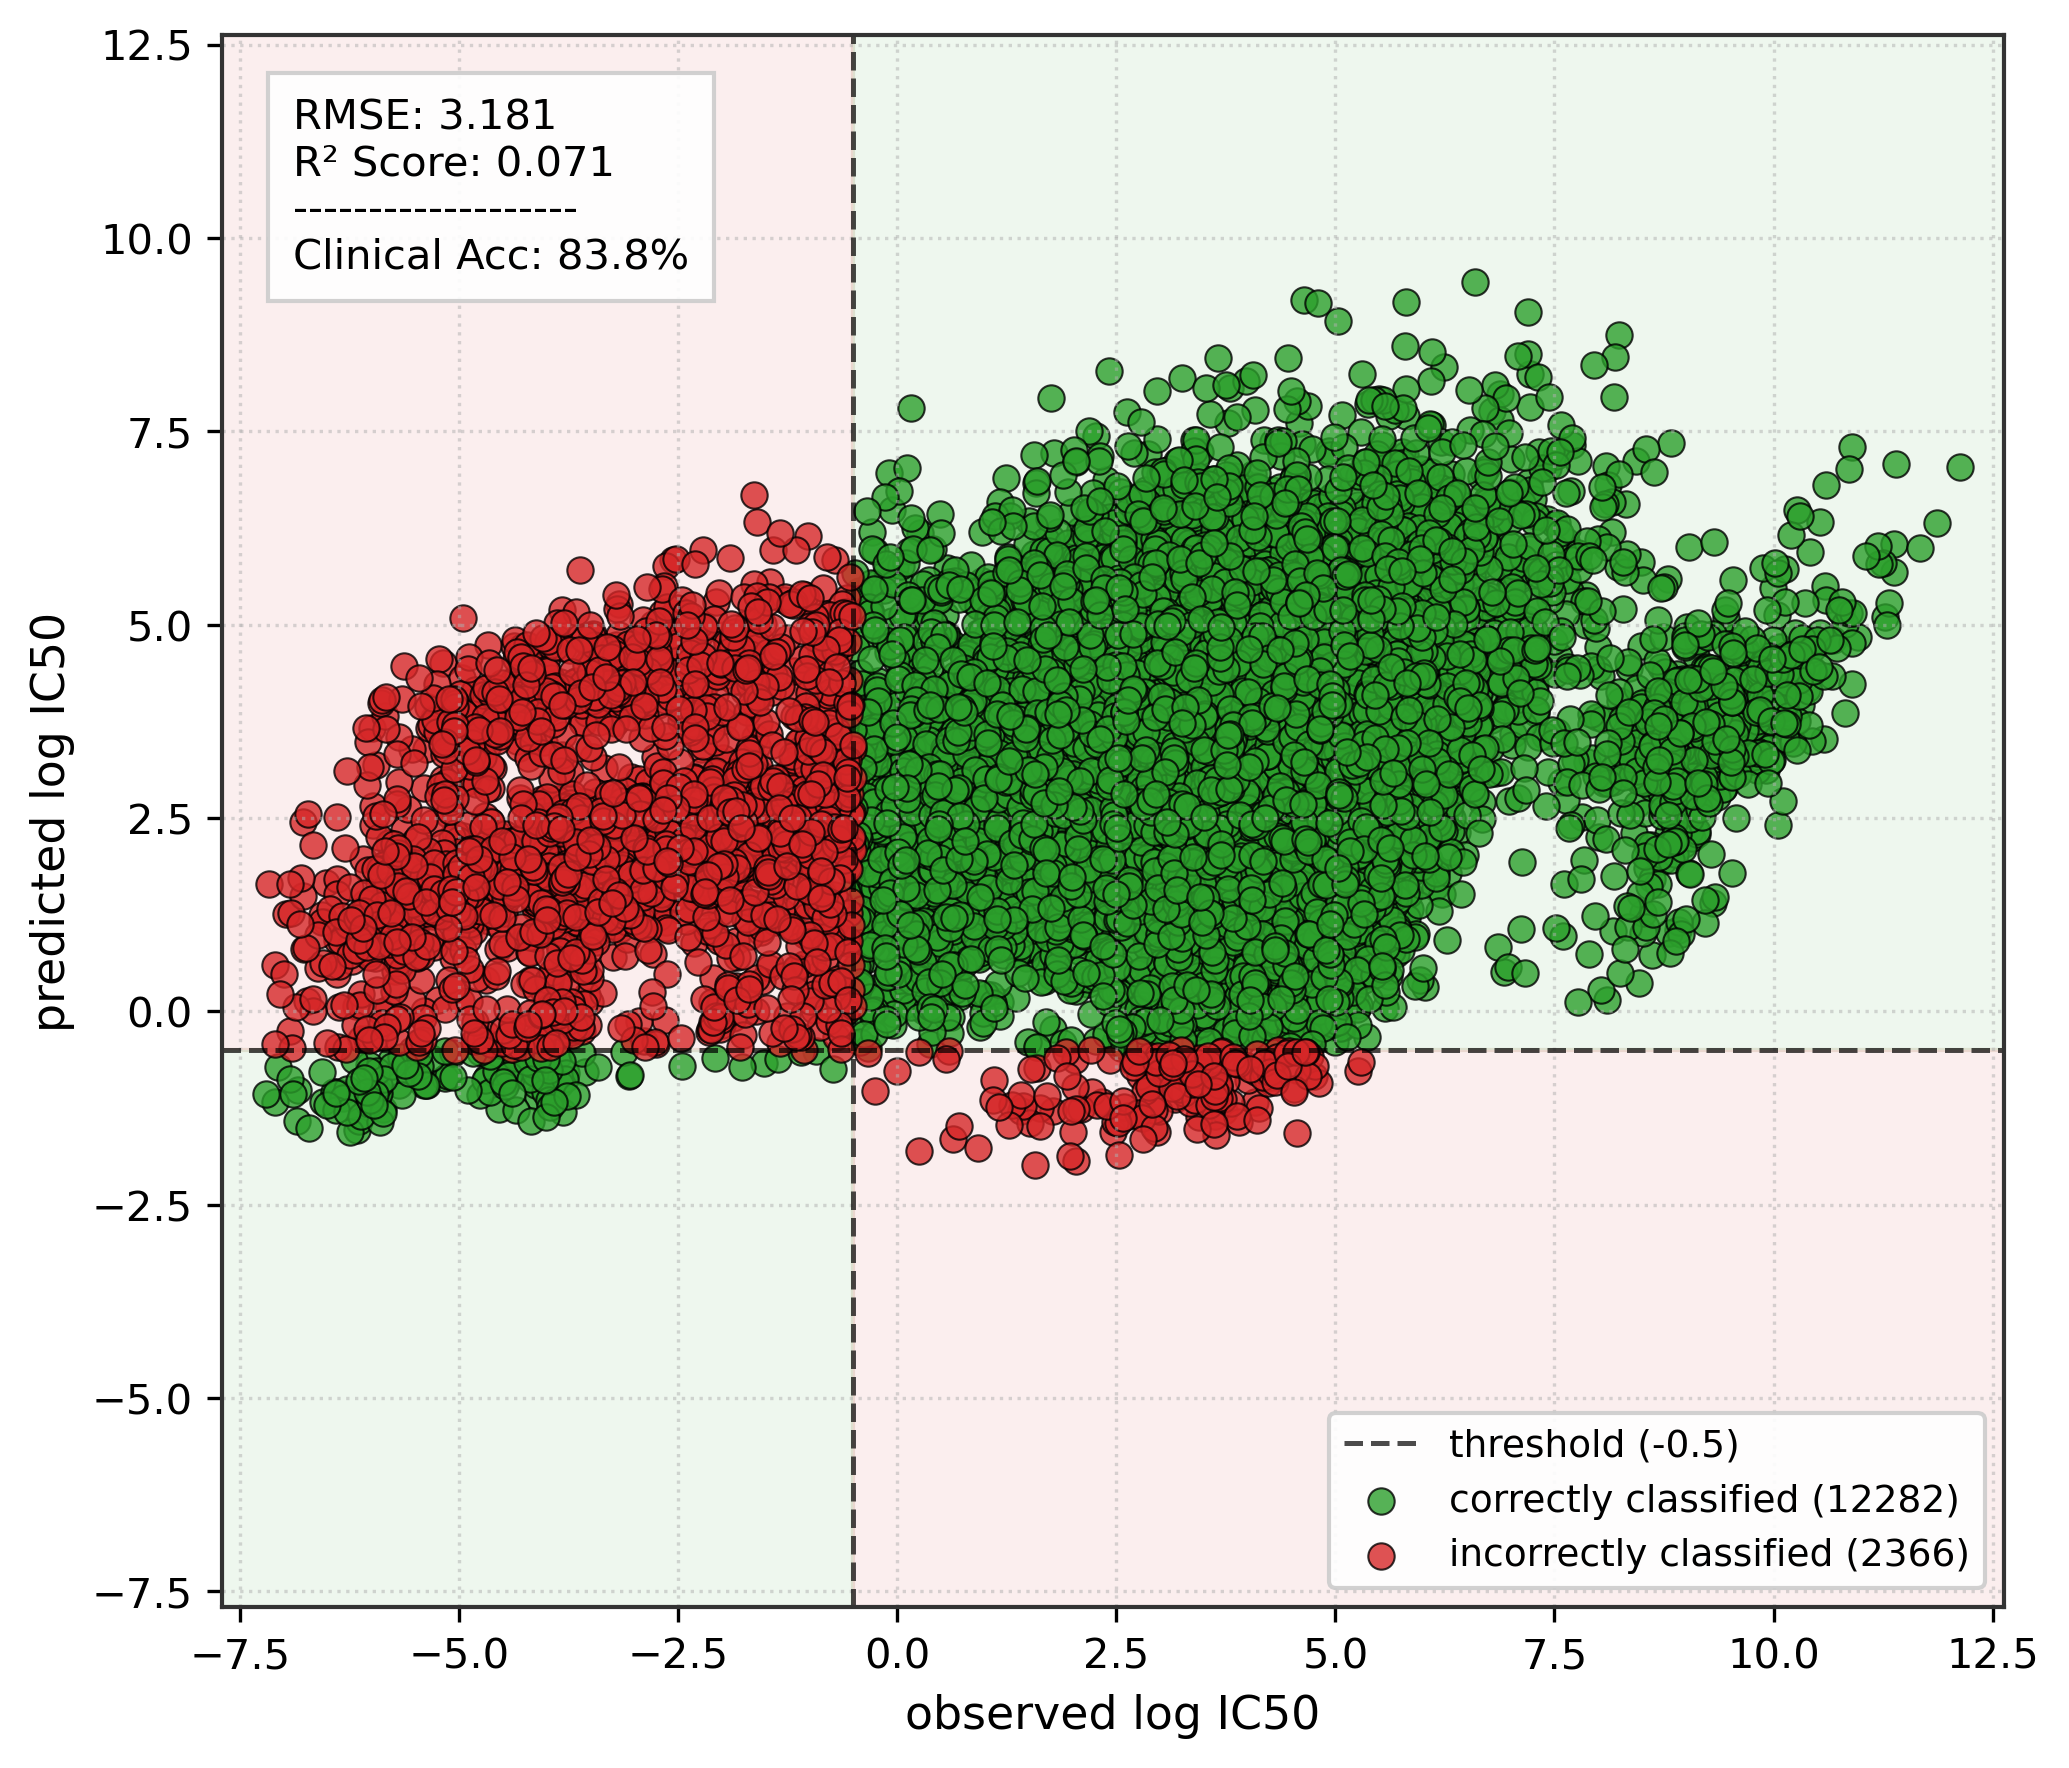

In [107]:
y_true = test_targets
y_pred = test_preds

# clinical parameters - important: i didn't research the clinical threshold, this is just a placeholder for demonstration purposes
THRESHOLD = -0.5  # threshold for sensitive vs resistant
DELTA = 1      # allowed floating-point deviation (tolerance band)

rmse_val = root_mean_squared_error(y_true, y_pred)
r2_val = r2_score(y_true, y_pred)

# Create a scatter plot of predicted vs. true values with a clinical threshold line
val_min = min(np.min(y_true), np.min(y_pred)) - 0.5
val_max = max(np.max(y_true), np.max(y_pred)) + 0.5

#plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.0

# threshold-based accuracy calculation
true_bin = (y_true >= THRESHOLD).astype(int)
pred_bin = (y_pred >= THRESHOLD).astype(int)
correct_thresh = (true_bin == pred_bin)
acc_thresh = np.mean(correct_thresh) * 100

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

ax.fill_between([val_min, THRESHOLD], val_min, THRESHOLD, color='#2ca02c', alpha=0.08) # bottom left (true sensitive)
ax.fill_between([THRESHOLD, val_max], THRESHOLD, val_max, color='#2ca02c', alpha=0.08) # top right (true resistant)
ax.fill_between([val_min, THRESHOLD], THRESHOLD, val_max, color='#d62728', alpha=0.08) # False Positive
ax.fill_between([THRESHOLD, val_max], val_min, THRESHOLD, color='#d62728', alpha=0.08) # False Negative

ax.axvline(THRESHOLD, color='black', linestyle='--', linewidth=1.2, alpha=0.7, label=f'threshold ({THRESHOLD})')
ax.axhline(THRESHOLD, color='black', linestyle='--', linewidth=1.2, alpha=0.7)

ax.scatter(y_true[correct_thresh], y_pred[correct_thresh], color='#2ca02c', alpha=0.8, s=40,
           edgecolors='black', linewidth=0.5, label=f'correctly classified ({np.sum(correct_thresh)})')
ax.scatter(y_true[~correct_thresh], y_pred[~correct_thresh], color='#d62728', alpha=0.8, s=40,
           edgecolors='black', linewidth=0.5, label=f'incorrectly classified ({np.sum(~correct_thresh)})')

info_text = (f"RMSE: {rmse_val:.3f}\n"
             f"R² Score: {r2_val:.3f}\n"
             f"-------------------\n"
             f"Clinical Acc: {acc_thresh:.1f}%")
ax.text(0.04, 0.96, info_text, transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='square,pad=0.6', facecolor='white', alpha=0.9, edgecolor='#cccccc'))

ax.set_xlabel("observed log IC50", fontsize=11)
ax.set_ylabel("predicted log IC50", fontsize=11)
ax.set_xlim(val_min, val_max)
ax.set_ylim(val_min, val_max)
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig("thesis_plot_threshold_accuracy.png", dpi=250, bbox_inches='tight')
plt.show()

Second, log IC50 Prediction with a margin of error range

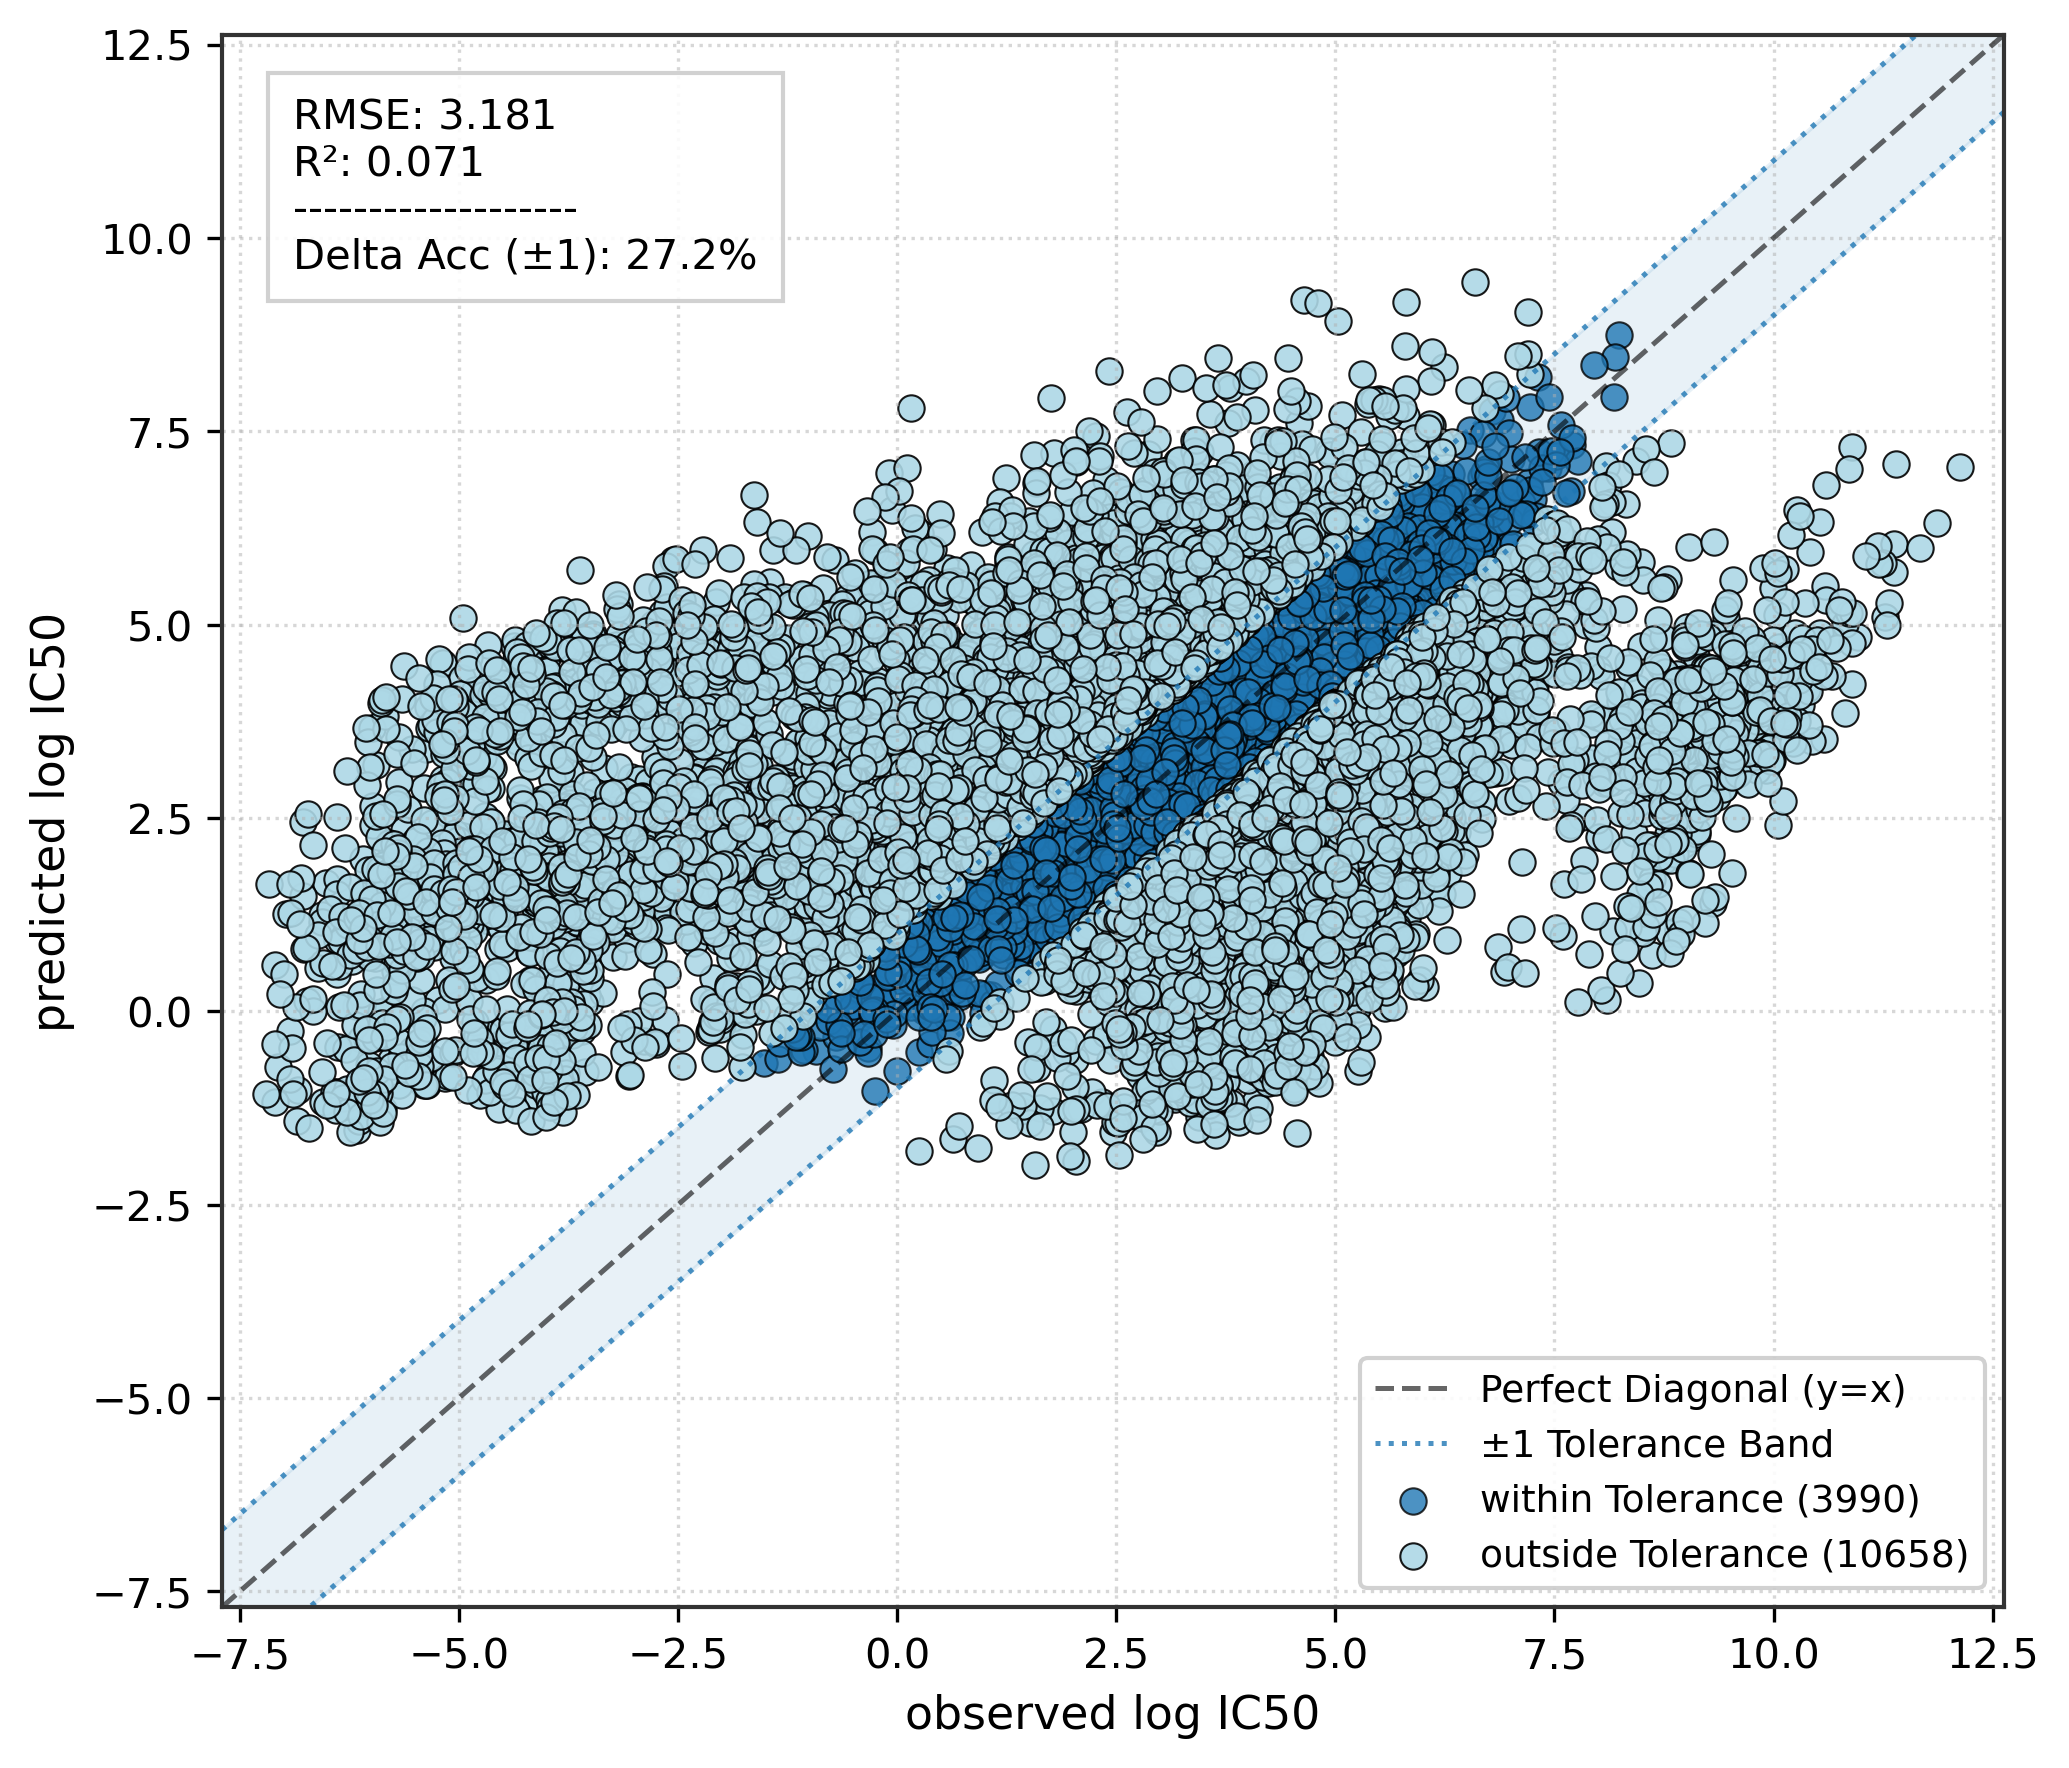

In [108]:
diff = np.abs(y_true - y_pred)
correct_delta = (diff <= DELTA)
acc_delta = np.mean(correct_delta) * 100

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

x_vals = np.linspace(val_min, val_max, 100)
ax.plot(x_vals, x_vals, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='Perfect Diagonal (y=x)')
ax.plot(x_vals, x_vals + DELTA, color='#1f77b4', linestyle=':', linewidth=1.2, alpha=0.8, label=f'±{DELTA} Tolerance Band')
ax.plot(x_vals, x_vals - DELTA, color='#1f77b4', linestyle=':', linewidth=1.2, alpha=0.8)
ax.fill_between(x_vals, x_vals - DELTA, x_vals + DELTA, color='#1f77b4', alpha=0.1)

# Data points
ax.scatter(y_true[correct_delta], y_pred[correct_delta], color='#1f77b4', alpha=0.8, s=40,
           edgecolors='black', linewidth=0.5, label=f'within Tolerance ({np.sum(correct_delta)})')
ax.scatter(y_true[~correct_delta], y_pred[~correct_delta], color='lightblue', alpha=0.9, s=40,
           edgecolors='black', linewidth=0.5, label=f'outside Tolerance ({np.sum(~correct_delta)})')

# Info-Box
info_text_delta = (f"RMSE: {rmse_val:.3f}\n"
                   f"R²: {r2_val:.3f}\n"
                   f"-------------------\n"
                   f"Delta Acc (±{DELTA}): {acc_delta:.1f}%")
ax.text(0.04, 0.96, info_text_delta, transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='square,pad=0.6', facecolor='white', alpha=0.9, edgecolor='#cccccc'))

ax.set_xlabel("observed log IC50", fontsize=11)
ax.set_ylabel("predicted log IC50", fontsize=11)
ax.set_xlim(val_min, val_max)
ax.set_ylim(val_min, val_max)
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig("thesis_plot_delta_accuracy.png", dpi=300, bbox_inches='tight')
plt.show()

Residuals versus predicted log IC50

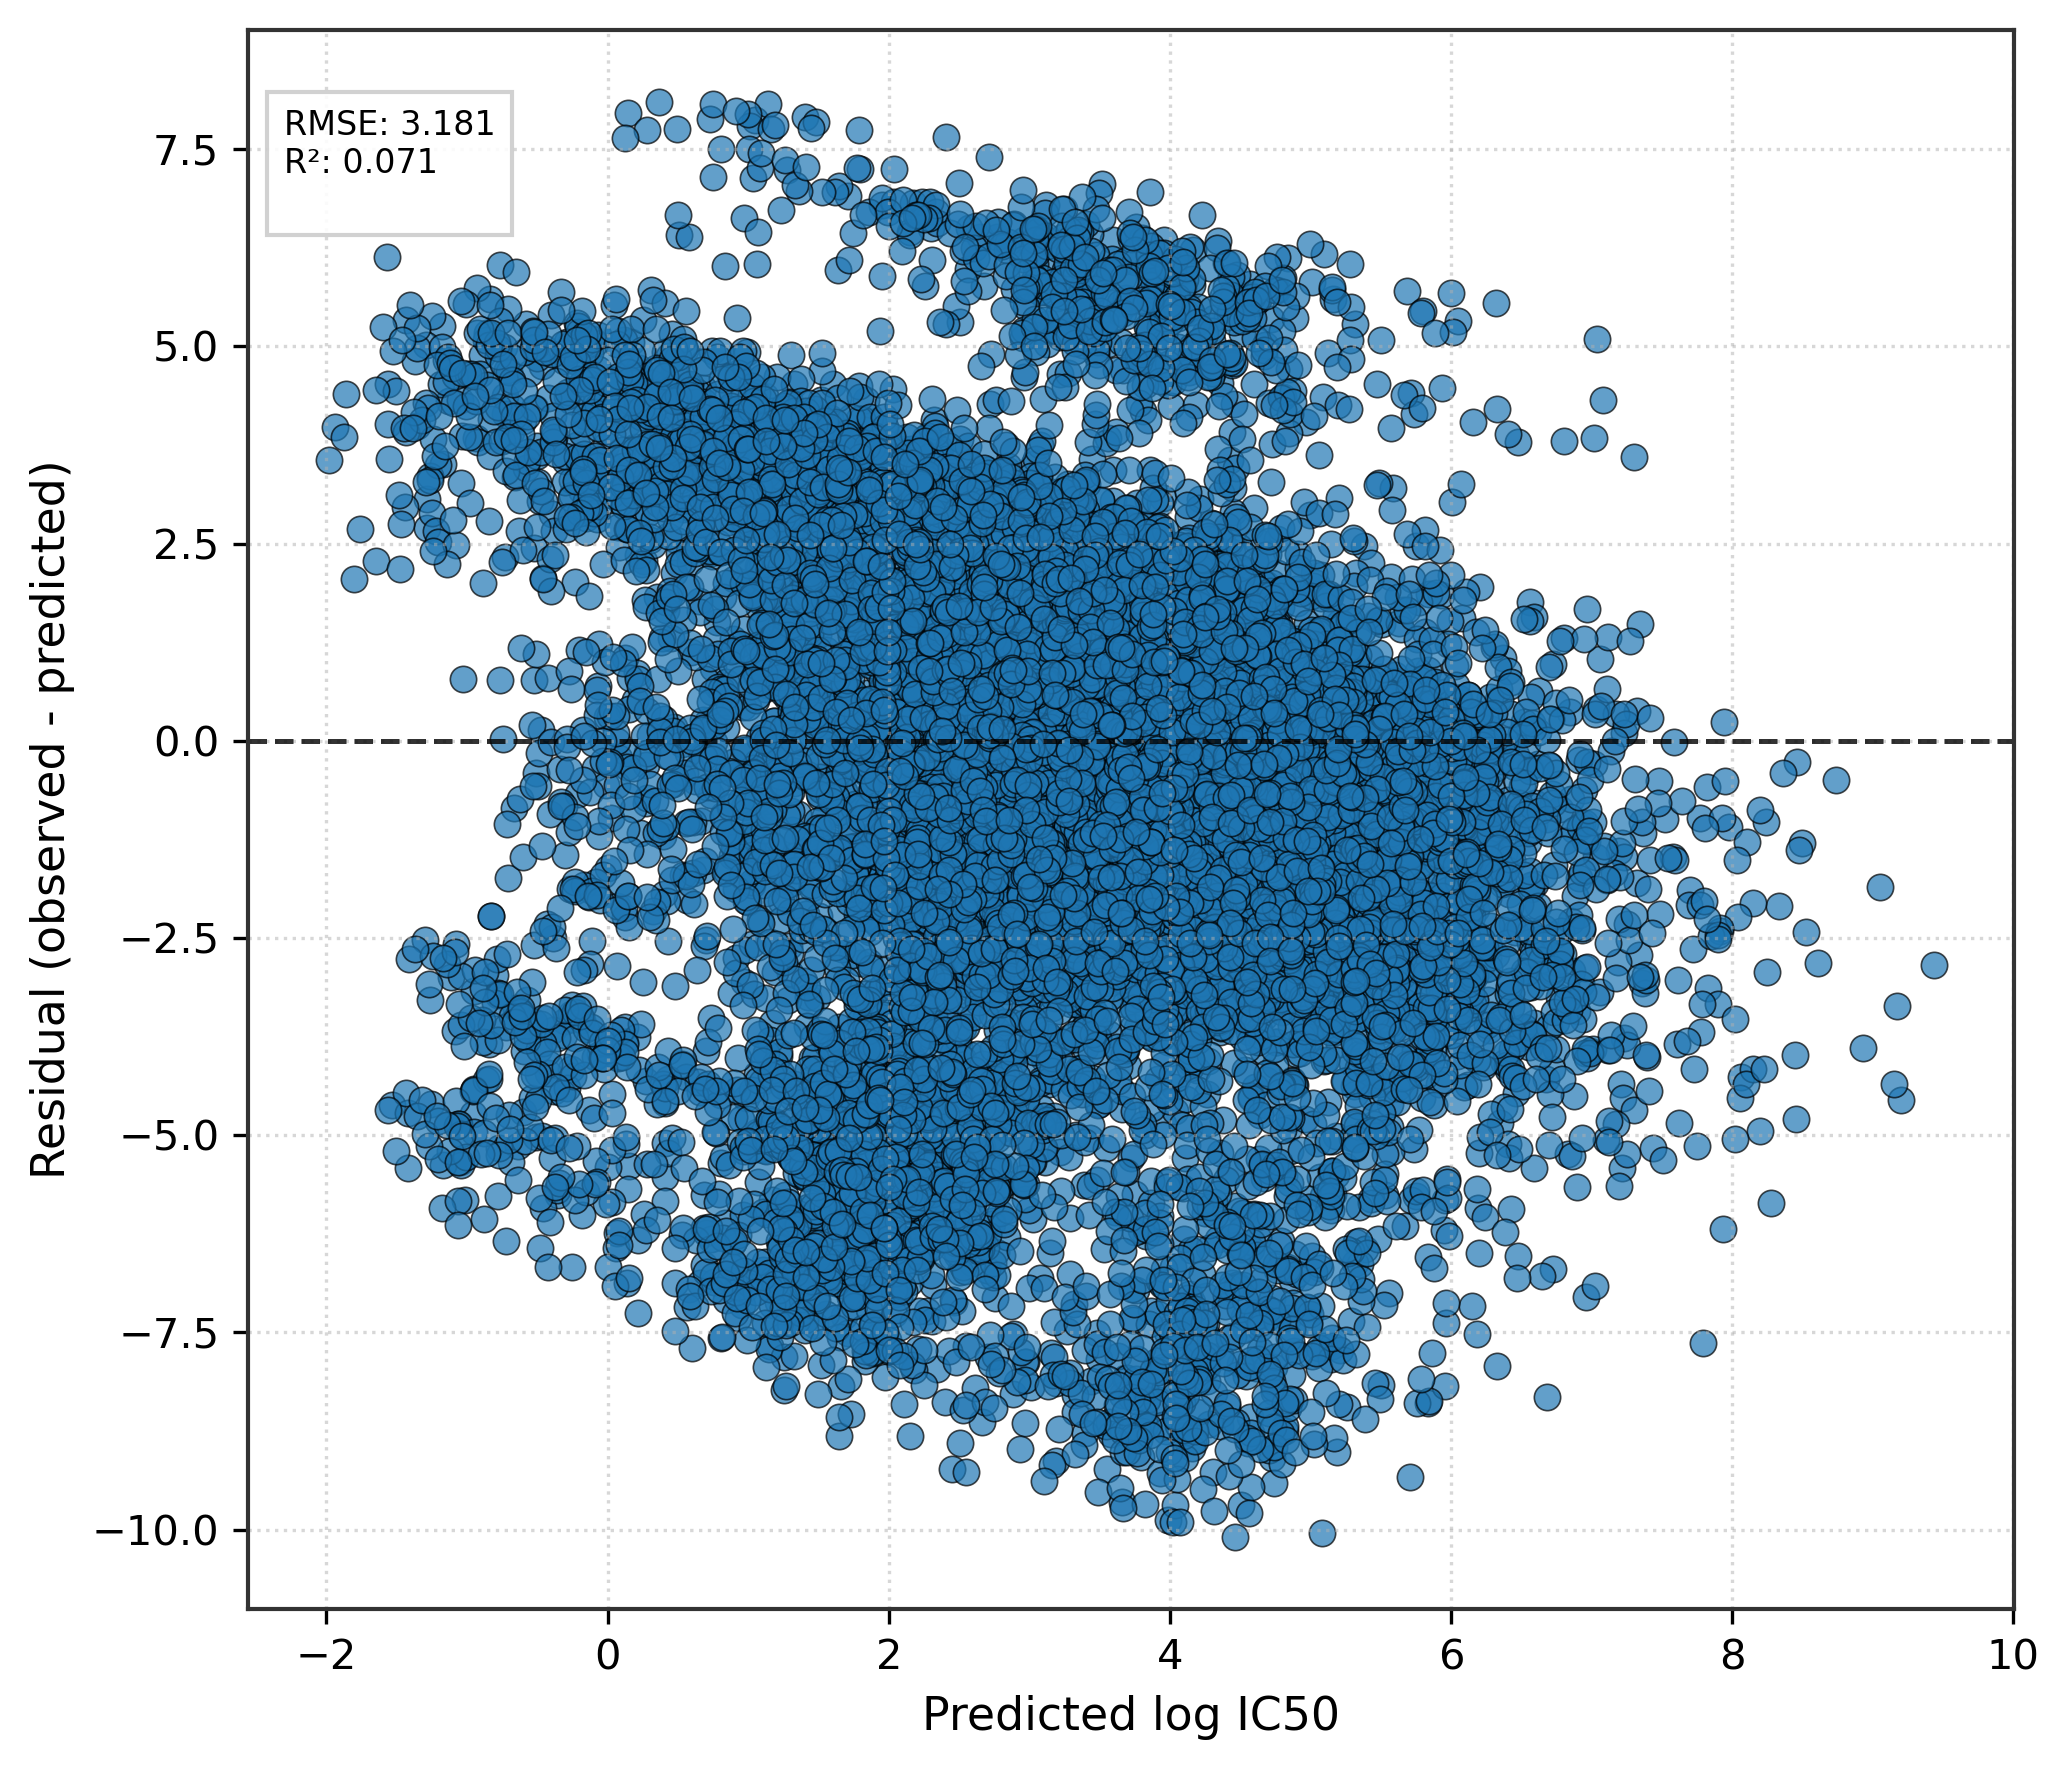

In [112]:
residuals = y_true - y_pred
rmse_val = root_mean_squared_error(y_true, y_pred)
r2_val = r2_score(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)
ax.scatter(y_pred, residuals, color='#1f77b4', alpha=0.7, s=40, edgecolors='black', linewidth=0.4)
ax.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)

ax.set_xlabel("Predicted log IC50", fontsize=11)
ax.set_ylabel("Residual (observed - predicted)", fontsize=11)
ax.grid(True, linestyle=':', alpha=0.5)

info_text = (
    f"RMSE: {rmse_val:.3f}\n"
    f"R²: {r2_val:.3f}\n"
)
ax.text(0.02, 0.95, info_text, transform=ax.transAxes, fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#cccccc'))

plt.tight_layout()
plt.savefig("residuals_vs_predicted.png", dpi=250, bbox_inches='tight')
plt.show()

## Grid Search

In [46]:
# Grid search cell for CrossAttentionFusionModel
import itertools
import copy
import time
import random

# grid (tune as desired)
param_grid = {
    "hidden_dim": [32, 64],
    "dropout": [0.3, 0.4],
    "num_tokens": [4, 8],
    "num_heads": [4],
    "optimizer": ["adam", "adamw", "sgd"],
    "lr": [1e-3, 5e-4],
    "weight_decay": [1e-2, 1e-3],
}

# settings for grid search training
grid_epochs = 20
early_stopping_patience = 4
seed = 42


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)


set_seed(seed)

# use existing variables if present
_device = device if "device" in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")
_gene_dim = X_genomic.shape[1]
_chem_dim = X_chem_train.shape[1]

combos = list(itertools.product(*param_grid.values()))
keys = list(param_grid.keys())

best_overall = {"val_r2": -float("inf"), "val_rmse": float("inf"), "params": None, "state_dict": None}
total = len(combos)
start_time = time.time()

for idx, combo in enumerate(combos, 1):
    params = dict(zip(keys, combo))
    set_seed(seed)
    train_loader, val_loader, test_loader = make_loaders(batch_size=128, seed=seed)

    model = CrossAttentionFusionModel(
        gene_dim=_gene_dim,
        chem_dim=_chem_dim,
        hidden_dim=params["hidden_dim"],
        num_tokens=params["num_tokens"],
        num_heads=params["num_heads"],
        dropout=params["dropout"],
    ).to(_device)

    criterion = nn.MSELoss()
    opt_name = params["optimizer"].lower()
    if opt_name == "adam":
        optimzer = optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    elif opt_name == "adamw":
        optimzer = optim.AdamW(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    elif opt_name == "sgd":
        optimzer = optim.SGD(model.parameters(), lr=params["lr"], momentum=0.9, weight_decay=params["weight_decay"])
    else:
        raise ValueError(f"Unknown optimizer {opt_name}")

    best_run_val = float("inf")
    best_run_r2 = -float("inf")
    run_no_improve = 0

    for ep in range(grid_epochs):
        model.train()
        for b_gen, b_chem, b_y in train_loader:
            b_gen = b_gen.to(_device)
            b_chem = b_chem.to(_device)
            b_y = b_y.to(_device).view(-1)

            optimzer.zero_grad()
            preds = model(b_gen, b_chem).view(-1)
            loss = criterion(preds, b_y)
            loss.backward()
            optimzer.step()

        model.eval()
        val_preds_list, val_targets_list = [], []
        with torch.no_grad():
            for b_gen, b_chem, b_y in val_loader:
                b_gen = b_gen.to(_device)
                b_chem = b_chem.to(_device)
                preds = model(b_gen, b_chem).view(-1).cpu().numpy()
                val_preds_list.append(preds)
                val_targets_list.append(b_y.numpy())
        val_preds = np.concatenate(val_preds_list)
        val_targets = np.concatenate(val_targets_list)
        val_rmse = root_mean_squared_error(val_targets, val_preds)
        val_r2 = r2_score(val_targets, val_preds)
        if (val_r2 > best_run_r2 + 1e-6) or (
            abs(val_r2 - best_run_r2) <= 1e-6 and val_rmse < best_run_val - 1e-6
        ):
            best_run_val = val_rmse
            best_run_r2 = val_r2
            run_no_improve = 0
            best_run_state = copy.deepcopy(model.state_dict())
        else:
            run_no_improve += 1
            if run_no_improve >= early_stopping_patience:
                break

    if (best_run_r2 > best_overall["val_r2"] + 1e-6) or (
        abs(best_run_r2 - best_overall["val_r2"]) <= 1e-6 and best_run_val < best_overall["val_rmse"] - 1e-6
    ):
        best_overall["val_r2"] = best_run_r2
        best_overall["val_rmse"] = best_run_val
        best_overall["params"] = params
        best_overall["state_dict"] = best_run_state

    elapsed = time.time() - start_time
    print(f"[{idx}/{total}] params={params} -> val_rmse={best_run_val:.4f} | val_r2={best_run_r2:.4f} | best_so_far={best_overall['val_rmse']:.4f} | elapsed={elapsed:.0f}s")

if best_overall["state_dict"] is not None:
    best_model = CrossAttentionFusionModel(
        gene_dim=_gene_dim,
        chem_dim=_chem_dim,
        hidden_dim=best_overall["params"]["hidden_dim"],
        num_tokens=best_overall["params"]["num_tokens"],
        num_heads=best_overall["params"]["num_heads"],
        dropout=best_overall["params"]["dropout"],
    ).to(_device)
    best_model.load_state_dict(best_overall["state_dict"])
    torch.save(best_model.state_dict(), "best_grid_model.pt")

print("GRID SEARCH DONE")
print("Best val_rmse:", best_overall["val_rmse"])
print("Best val_r2:", best_overall["val_r2"])
print("Best params:", best_overall["params"])

if best_overall["state_dict"] is not None:
    best_model.eval()
    val_preds_list, val_targets_list = [], []
    with torch.no_grad():
        for b_gen, b_chem, b_y in val_loader:
            b_gen = b_gen.to(_device)
            b_chem = b_chem.to(_device)
            preds = best_model(b_gen, b_chem).view(-1).cpu().numpy()
            val_preds_list.append(preds)
            val_targets_list.append(b_y.numpy())
    val_preds = np.concatenate(val_preds_list)
    val_targets = np.concatenate(val_targets_list)
    ss_res = np.sum((val_targets - val_preds) ** 2)
    ss_tot = np.sum((val_targets - np.mean(val_targets)) ** 2)
    best_val_r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    print("Best val_r2:", best_val_r2)
else:
    print("No best model found to evaluate r2.")

[1/96] params={'hidden_dim': 32, 'dropout': 0.3, 'num_tokens': 4, 'num_heads': 4, 'optimizer': 'adam', 'lr': 0.001, 'weight_decay': 0.01} -> val_rmse=2.3605 | best_so_far=2.3605 | elapsed=247s
[2/96] params={'hidden_dim': 32, 'dropout': 0.3, 'num_tokens': 4, 'num_heads': 4, 'optimizer': 'adam', 'lr': 0.001, 'weight_decay': 0.001} -> val_rmse=2.4218 | best_so_far=2.3605 | elapsed=481s
[3/96] params={'hidden_dim': 32, 'dropout': 0.3, 'num_tokens': 4, 'num_heads': 4, 'optimizer': 'adam', 'lr': 0.0005, 'weight_decay': 0.01} -> val_rmse=2.4670 | best_so_far=2.3605 | elapsed=707s
[4/96] params={'hidden_dim': 32, 'dropout': 0.3, 'num_tokens': 4, 'num_heads': 4, 'optimizer': 'adam', 'lr': 0.0005, 'weight_decay': 0.001} -> val_rmse=2.5805 | best_so_far=2.3605 | elapsed=826s
[5/96] params={'hidden_dim': 32, 'dropout': 0.3, 'num_tokens': 4, 'num_heads': 4, 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.01} -> val_rmse=2.4048 | best_so_far=2.3605 | elapsed=1046s
[6/96] params={'hidden_dim': 